In [1]:
import numpy as np

In [35]:
# array[
#    line index of interest,
#    station index
# ]
d = np.array([
    [9,9,3,4,8,7],
    [12,5,6,4,5,9],
])

d

array([[ 9,  9,  3,  4,  8,  7],
       [12,  5,  6,  4,  5,  9]])

In [37]:
# array[
#    line index of interest,
#    station index
# ]
t = np.array([
    [np.nan,2,1,2,2,1],
    [np.nan,2,3,1,3,4]
])

t

array([[nan,  2.,  1.,  2.,  2.,  1.],
       [nan,  2.,  3.,  1.,  3.,  4.]])

In [41]:
d.cumsum(axis=1)

array([[ 9, 18, 21, 25, 33, 40],
       [12, 17, 23, 27, 32, 41]])

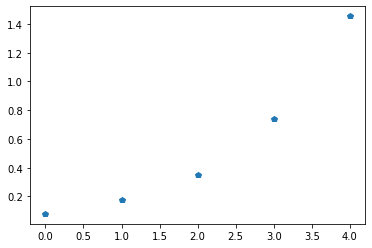

In [118]:
from timeit import timeit
import matplotlib.pyplot as plt

def fastest_to_station(l,s):
    # s: station index
    # l: line index
    if s > 0:
        return min(
            fastest_to_station(l,s-1)+d[l,s],
            fastest_to_station(int(l == 0),s-1)+t[l,s]+d[l,s]
        )
    return d[l,0]

plt.plot([timeit(lambda: fastest_to_station(1,x), number=10000) for x in range(1,6)], "p")

In [134]:
fastest = {}

def fastest_to_station(l,s):
    # s: station index
    # l: line index
    if s > 0:
        if (l,s) in fastest:
            return fastest[(l,s)]
        stay = fastest_to_station(l,s-1)+d[l,s]
        swap = fastest_to_station(int(l == 0),s-1)+t[l,s]+d[l,s]
        fastest[(l,s)] = min(stay, swap)
        return fastest[(l,s)]
    return d[l,0]

# plt.plot([timeit(lambda: fastest_to_station(1,i), number=10000) for i in range(6)], "p")

In [135]:
[fastest_to_station(0,i) for i in range(6)]

[9, 18, 20.0, 24.0, 32.0, 38.0]

In [137]:
[fastest_to_station(1,i) for i in range(6)]

[12, 16.0, 22.0, 25.0, 30.0, 39.0]